In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(r"C:\Users\sahil\OneDrive\ドキュメント\Automobile Warranty Claim\data\01.Raw\crop_yield_dataset.csv")

In [4]:
df.head()

,Crop,Region,Soil_Type,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Irrigation,Pesticides_Used_kg,Planting_Density,Previous_Crop,Yield_ton_per_ha
0,Maize,Region_C,Sandy,7.01,1485.4,19.7,40.3,105.1,Drip,10.2,23.2,Rice,101.48
1,Barley,Region_D,Loam,5.79,399.4,29.1,55.4,221.8,Sprinkler,35.5,7.4,Barley,127.39
2,Rice,Region_C,Clay,7.24,980.9,30.5,74.4,61.2,Sprinkler,40.0,5.1,Wheat,68.99
3,Maize,Region_D,Loam,6.79,1054.3,26.4,62.0,257.8,Drip,42.7,23.7,NaN,169.06
4,Maize,Region_D,Sandy,5.96,744.6,20.4,70.9,195.8,Drip,25.5,15.6,Maize,118.71


In [9]:
df.tail()

,Crop,Region,Soil_Type,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Irrigation,Pesticides_Used_kg,Planting_Density,Previous_Crop,Yield_ton_per_ha
9995,Barley,Region_A,Clay,5.84,890.4,28.5,68.6,82.5,Flood,4.0,24.1,Wheat,79.83
9996,Maize,Region_A,Sandy,6.91,614.2,30.0,84.2,85.2,NaN,21.7,8.3,Maize,68.24
9997,Wheat,Region_A,Clay,6.98,842.0,22.6,75.1,249.2,Sprinkler,8.8,18.1,Rice,159.29
9998,Wheat,Region_D,Sandy,7.27,924.2,26.8,50.8,146.1,Sprinkler,3.3,18.1,Maize,99.08
9999,Rice,Region_C,Sandy,5.95,247.0,31.1,66.2,223.4,Flood,18.7,12.1,Rice,121.30


In [7]:
print("Number of rows :- ",df.shape[0])
print("Number of columns :- ",df.shape[1])

Number of rows :-  10000
Number of columns :-  13


In [10]:
df.columns

Index(['Crop', 'Region', 'Soil_Type', 'Soil_pH', 'Rainfall_mm',
       'Temperature_C', 'Humidity_pct', 'Fertilizer_Used_kg', 'Irrigation',
       'Pesticides_Used_kg', 'Planting_Density', 'Previous_Crop',
       'Yield_ton_per_ha'],
      dtype='object')

In [11]:
df.dtypes

Crop                   object
Region                 object
Soil_Type              object
Soil_pH               float64
Rainfall_mm           float64
Temperature_C         float64
Humidity_pct          float64
Fertilizer_Used_kg    float64
Irrigation             object
Pesticides_Used_kg    float64
Planting_Density      float64
Previous_Crop          object
Yield_ton_per_ha      float64
dtype: object

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Crop                10000 non-null  object 
 1   Region              10000 non-null  object 
 2   Soil_Type           10000 non-null  object 
 3   Soil_pH             10000 non-null  float64
 4   Rainfall_mm         10000 non-null  float64
 5   Temperature_C       10000 non-null  float64
 6   Humidity_pct        10000 non-null  float64
 7   Fertilizer_Used_kg  10000 non-null  float64
 8   Irrigation          7462 non-null   object 
 9   Pesticides_Used_kg  10000 non-null  float64
 10  Planting_Density    10000 non-null  float64
 11  Previous_Crop       7969 non-null   object 
 12  Yield_ton_per_ha    10000 non-null  float64
dtypes: float64(8), object(5)
memory usage: 1015.8+ KB


In [13]:
df.isnull().sum()/len(df) * 100

Crop                   0.00
Region                 0.00
Soil_Type              0.00
Soil_pH                0.00
Rainfall_mm            0.00
Temperature_C          0.00
Humidity_pct           0.00
Fertilizer_Used_kg     0.00
Irrigation            25.38
Pesticides_Used_kg     0.00
Planting_Density       0.00
Previous_Crop         20.31
Yield_ton_per_ha       0.00
dtype: float64

In [14]:
df["Irrigation"].value_counts()

Irrigation
Flood        2530
Drip         2472
Sprinkler    2460
Name: count, dtype: int64

In [15]:
df["Previous_Crop"].value_counts()

Previous_Crop
Rice      2072
Maize     1972
Barley    1965
Wheat     1960
Name: count, dtype: int64

In [16]:
df["Irrigation"] = df["Irrigation"].fillna("Unknown")
df["Previous_Crop"] = df["Previous_Crop"].fillna("None")

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.describe()

,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Pesticides_Used_kg,Planting_Density,Yield_ton_per_ha
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.516693,843.66467,24.975750,60.052550,175.083290,25.055500,14.997930,117.891105
std,0.574761,373.67076,5.790631,17.317097,71.964157,14.353483,5.833087,37.972664
min,5.500000,200.00000,15.000000,30.000000,50.000000,0.000000,5.000000,28.450000
25%,6.020000,518.00000,20.000000,45.100000,113.300000,12.600000,9.900000,87.135000
50%,6.520000,845.30000,24.900000,60.200000,175.000000,25.300000,15.000000,117.705000
75%,7.010000,1161.85000,30.100000,75.100000,237.900000,37.500000,20.100000,149.147500
max,7.500000,1499.70000,35.000000,90.000000,300.000000,50.000000,25.000000,207.210000


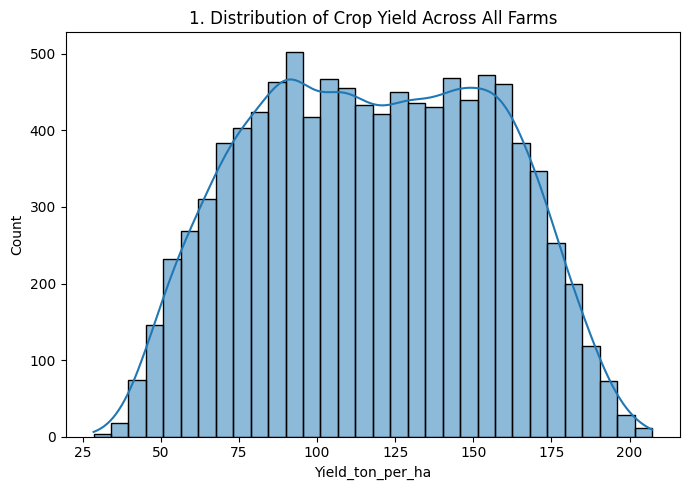

In [20]:
fig = plt.figure(figsize=(7,5))
sns.histplot(df['Yield_ton_per_ha'], kde=True)
plt.title('1. Distribution of Crop Yield Across All Farms')
plt.tight_layout()
plt.show()


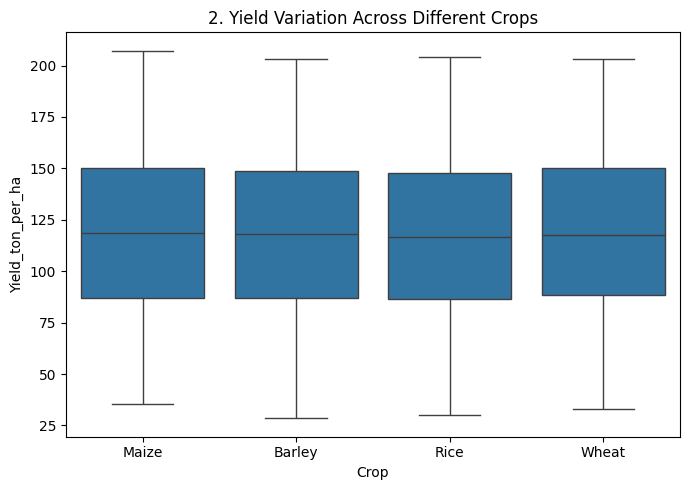

In [21]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Crop', y='Yield_ton_per_ha', data=df)
plt.title('2. Yield Variation Across Different Crops')
plt.tight_layout()
plt.show()

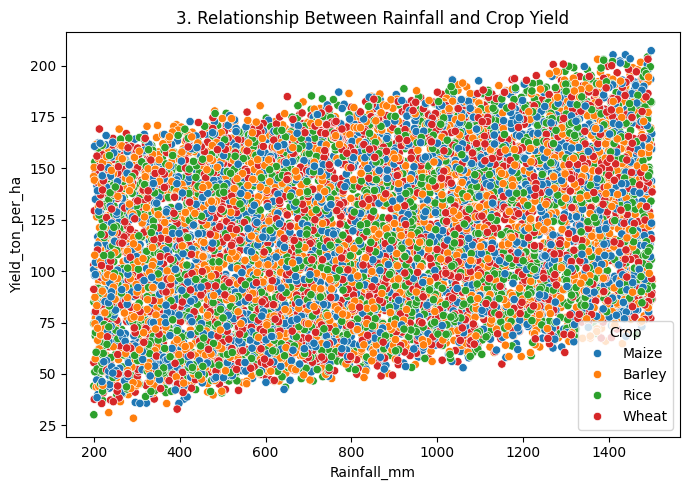

In [23]:
fig = plt.figure(figsize=(7,5))
sns.scatterplot(x='Rainfall_mm', y='Yield_ton_per_ha', hue='Crop', data=df)
plt.title('3. Relationship Between Rainfall and Crop Yield')
plt.tight_layout()
plt.show()


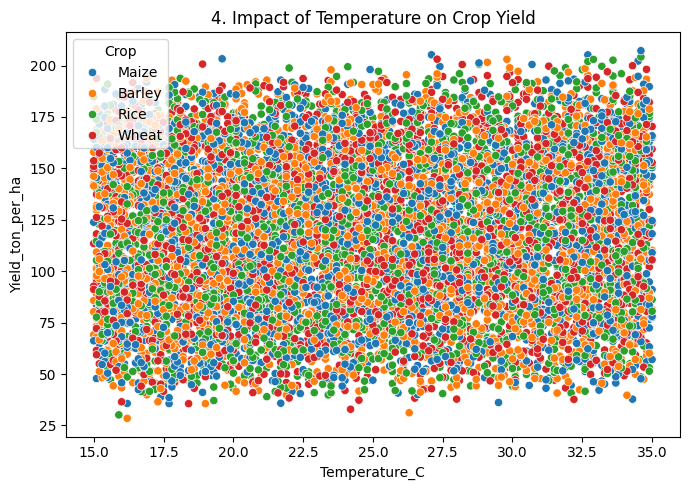

In [24]:
fig = plt.figure(figsize=(7,5))
sns.scatterplot(x='Temperature_C', y='Yield_ton_per_ha', hue='Crop', data=df)
plt.title('4. Impact of Temperature on Crop Yield')
plt.tight_layout()
plt.show()

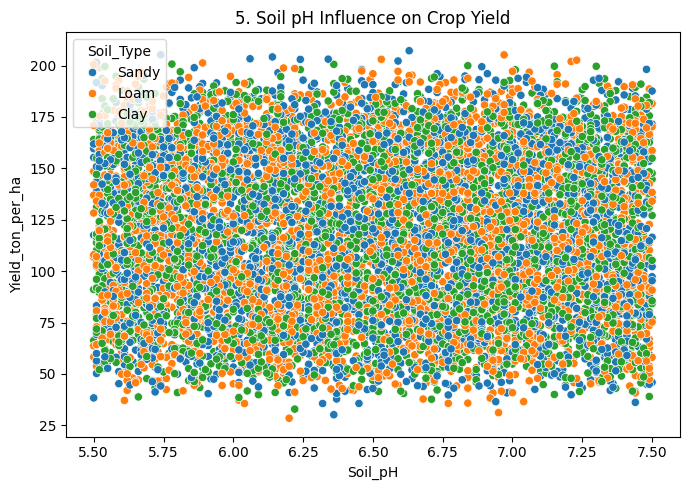

In [26]:
fig = plt.figure(figsize=(7,5))
sns.scatterplot(x='Soil_pH', y='Yield_ton_per_ha', hue='Soil_Type', data=df)
plt.title('5. Soil pH Influence on Crop Yield')
plt.tight_layout()
plt.show()

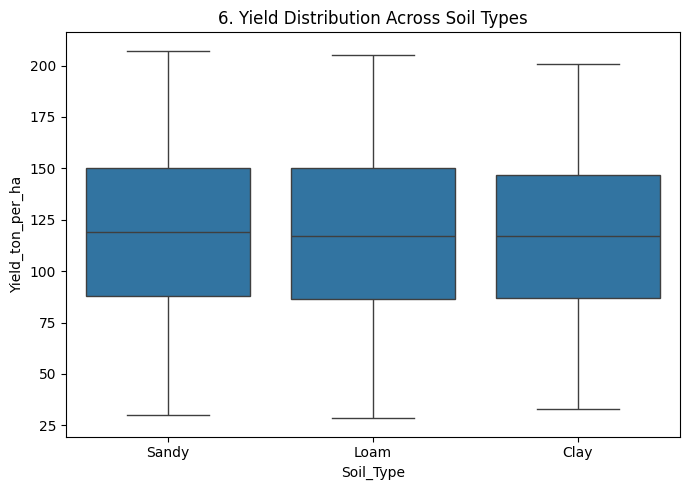

In [27]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Soil_Type', y='Yield_ton_per_ha', data=df)
plt.title('6. Yield Distribution Across Soil Types')
plt.tight_layout()
plt.show()

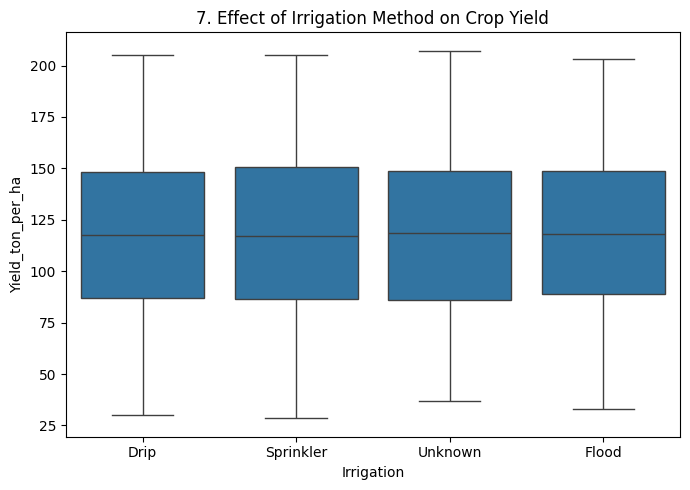

In [28]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Irrigation', y='Yield_ton_per_ha', data=df)
plt.title('7. Effect of Irrigation Method on Crop Yield')
plt.tight_layout()
plt.show()

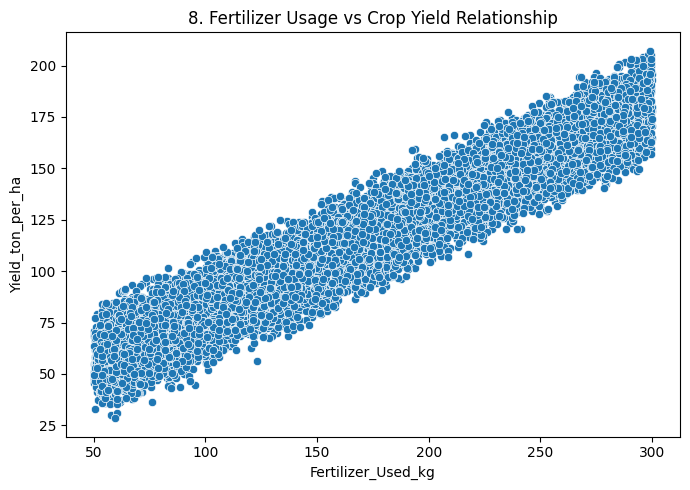

In [29]:
fig = plt.figure(figsize=(7,5))
sns.scatterplot(x='Fertilizer_Used_kg', y='Yield_ton_per_ha', data=df)
plt.title('8. Fertilizer Usage vs Crop Yield Relationship')
plt.tight_layout()
plt.show()

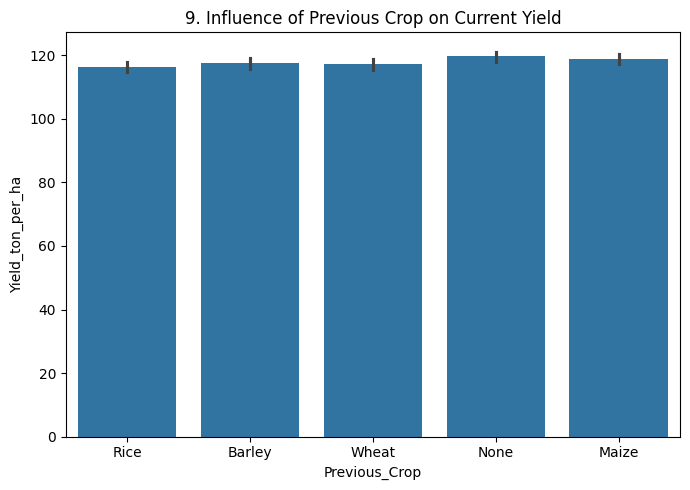

In [31]:
fig = plt.figure(figsize=(7,5))
sns.barplot(x='Previous_Crop', y='Yield_ton_per_ha', data=df)
plt.title('9. Influence of Previous Crop on Current Yield')
plt.tight_layout()
plt.show()

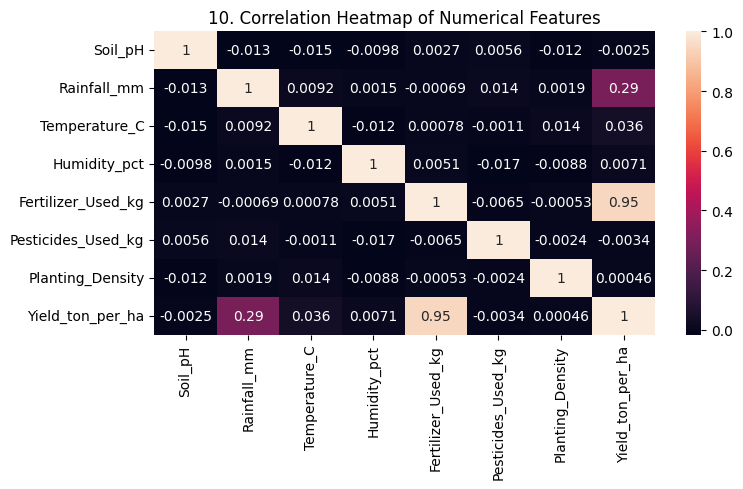

In [45]:
corr = df.corr(numeric_only=True)
plt.figure(figsize = (8,5))
sns.heatmap(corr, annot=True)
plt.title('10. Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

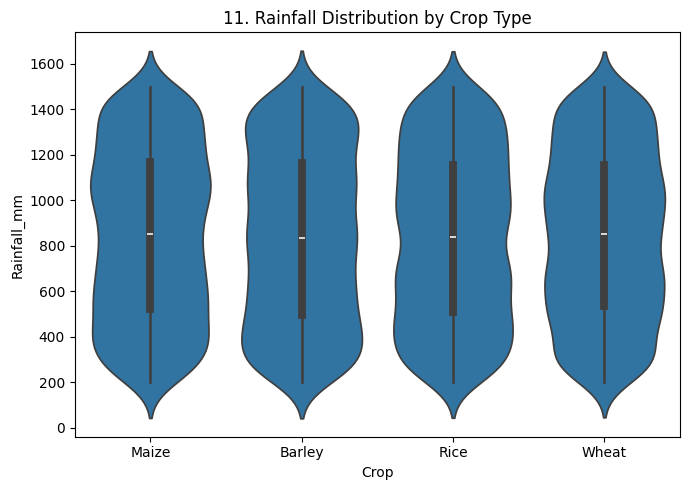

In [42]:
fig = plt.figure(figsize=(7,5))
sns.violinplot(x='Crop', y='Rainfall_mm', data=df)
plt.title('11. Rainfall Distribution by Crop Type')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, '12. Influence of Previous Crop on Current Yield')

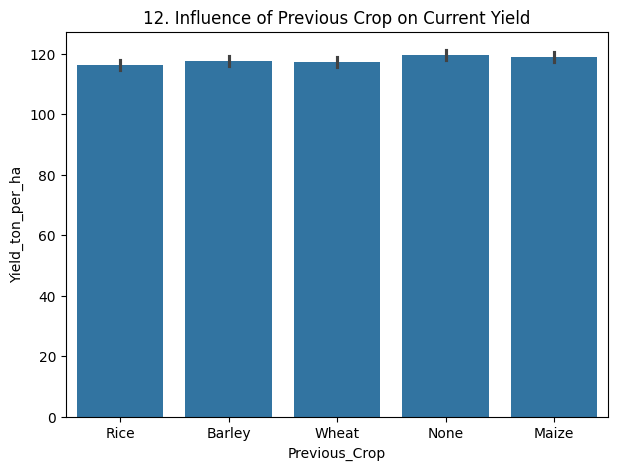

In [44]:
fig = plt.figure(figsize=(7,5))
sns.barplot(x='Previous_Crop', y='Yield_ton_per_ha', data=df)
plt.title('12. Influence of Previous Crop on Current Yield')


In [46]:
df.select_dtypes(include='number').corr()

,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Pesticides_Used_kg,Planting_Density,Yield_ton_per_ha
Soil_pH,1.000000,-0.013136,-0.015249,-0.009788,0.002719,0.005638,-0.011672,-0.002520
Rainfall_mm,-0.013136,1.000000,0.009170,0.001472,-0.000686,0.013530,0.001924,0.294182
Temperature_C,-0.015249,0.009170,1.000000,-0.011534,0.000781,-0.001114,0.013900,0.035878
Humidity_pct,-0.009788,0.001472,-0.011534,1.000000,0.005125,-0.016729,-0.008843,0.007116
Fertilizer_Used_kg,0.002719,-0.000686,0.000781,0.005125,1.000000,-0.006475,-0.000534,0.945808
Pesticides_Used_kg,0.005638,0.013530,-0.001114,-0.016729,-0.006475,1.000000,-0.002407,-0.003400
Planting_Density,-0.011672,0.001924,0.013900,-0.008843,-0.000534,-0.002407,1.000000,0.000458
Yield_ton_per_ha,-0.002520,0.294182,0.035878,0.007116,0.945808,-0.003400,0.000458,1.000000


In [47]:
df.to_csv("Cleaned_Crop_Yield.csv",index = False)